In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df = pd.read_csv("C:/Users/taram/OneDrive/Documents/esilv/A5/BI pipeline/data.csv")
df.head(10)


,energy_consumption_llm_total,response_token_length,response_duration,total_duration,model_size,adj_count,polysyllabcount,long_word_count
0,0.000022,77.0,8.566705e+09,1.131123e+10,2.000000e+09,1.0,0.0,2.0
1,0.000008,26.0,2.843215e+09,3.735246e+09,2.000000e+09,1.0,1.0,1.0
2,0.000072,408.0,4.735760e+10,4.826106e+10,2.000000e+09,0.0,0.0,2.0
3,0.000078,446.0,5.152275e+10,5.242146e+10,2.000000e+09,0.0,1.0,1.0
4,0.000057,325.0,3.704593e+10,3.822720e+10,2.000000e+09,1.0,2.0,3.0
5,0.000012,38.0,4.375991e+09,5.435993e+09,2.000000e+09,1.0,2.0,4.0
6,0.000020,25.0,3.080001e+09,4.555325e+09,2.000000e+09,1.0,2.0,4.0
7,0.000072,384.0,4.454998e+10,4.618705e+10,2.000000e+09,3.0,4.0,4.0
8,0.000057,325.0,3.728621e+10,3.857219e+10,2.000000e+09,1.0,0.0,0.0
9,0.000008,20.0,2.097542e+09,3.544711e+09,2.000000e+09,0.0,1.0,7.0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [17]:
# select the machine learning model
def select_model(model_name):
    models = {
        "random_forest": RandomForestRegressor(n_estimators=100,random_state=42,max_depth=15,n_jobs=-1),
        "decision_tree": DecisionTreeRegressor(),
        "xgboost": xgb.XGBRegressor(),
        "linear_regression": LinearRegression(),
    }
    return models.get(model_name, LinearRegression())

# train the model and evaluate
def train_and_evaluate(model_name, X_train, X_test, y_train, y_test):
    model = select_model(model_name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"mse: {mse} & mae: {mae} & r²: {r2}")

    plot_true_vs_predicted(y_test, y_pred,model_name)

    return model, mse, mae, r2

def plot_true_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(5, 3))
    plt.scatter(y_true, y_pred, alpha=0.5, color='blue', label='Predicted')
    plt.plot(y_true, y_true, color='red', label='True')
    plt.title(f'True vs. Predicted Energy Consumption_{model_name}')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
X = df[['response_token_length', 'response_duration', 
        'model_size',
        'adj_count', 'polysyllabcount', 'long_word_count']]
y = df['energy_consumption_llm_total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mse: 4.039415791317722e-09 & mae: 6.896921413127833e-06 & r²: 0.9849131513059202


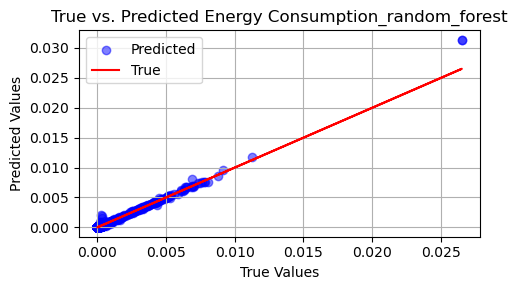

mse: 6.814111759079539e-09 & mae: 6.713174538102248e-06 & r²: 0.9745499155311648


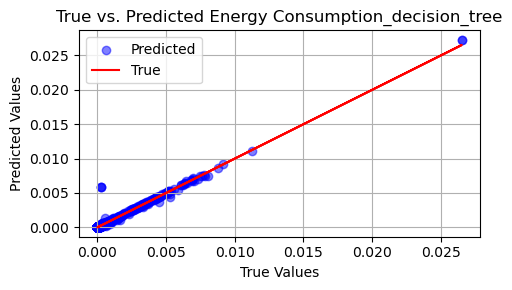

mse: 9.245861784657488e-08 & mae: 2.290092864349472e-05 & r²: 0.6546755149808487


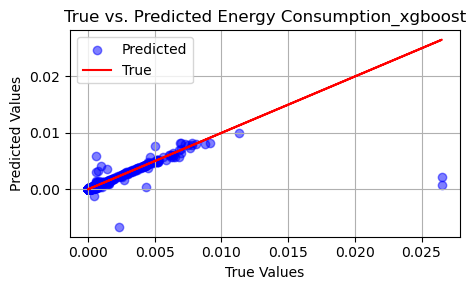

mse: 7.864018418381561e-08 & mae: 9.091044599009291e-05 & r²: 0.7062861014194435


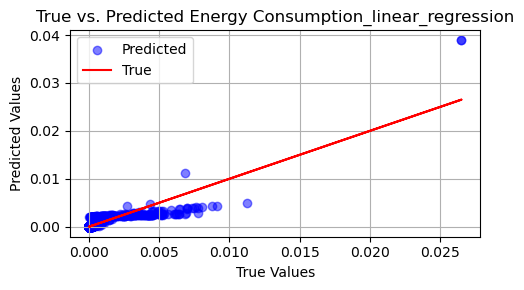

In [19]:
model_names = ["random_forest",  "decision_tree", "xgboost", "linear_regression"]
models = []
for model_name in model_names:
    model,_,_,_=train_and_evaluate(model_name, X_train, X_test, y_train, y_test)
    models.append(model)

In [20]:
import joblib
joblib.dump(models[0], "random_forest.pkl") 


['random_forest.pkl']